# Semantic Segmentation: U-Net from Scratch

**Dataset:** Oxford-IIIT Pet  
**Task:** one label per pixel  
**Architecture:** U-Net

In [1]:
import os
import random
import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import datasets
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_everything()

# Device — accelerator="auto" in the Trainer handles the rest
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"PyTorch {torch.__version__}  |  accelerator: {device}")

PyTorch 2.4.1  |  accelerator: mps


---
## 1 — Dataset: Oxford-IIIT Pets

Each image comes with a trimap mask: pet, background, and border.
Here we merge pet + border into one foreground class and train a binary segmenter.

In [2]:
# Experiment configuration 
IMAGE_SIZE = 128    # power of 2 → spatial sizes halve evenly at every level
BATCH_SIZE = 16
BASE_CHANNELS = 32     
MAX_EPOCHS = 25
LR = 1e-3
WEIGHT_DECAY = 1e-5

NUM_WORKERS = 0   # adjust to the number of CPU cores available on your machine

TRAIN_SUBSET = 2000   # use a subset for quick iteration; set None to use all
VAL_SUBSET = 400

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [3]:
class OxfordPetDataset(torch.utils.data.Dataset):
    """
    Oxford-IIIT Pet dataset wrapped for binary segmentation.

    Input:  RGB image, resized to IMAGE_SIZE x IMAGE_SIZE, ImageNet-normalized.
    Target: binary mask — 1 = pet (foreground), 0 = background.
            Trimap values 1 (pet) and 3 (ambiguous border) → foreground.
            Trimap value 2 (background) → background.

    Augmentation: random horizontal flip, applied identically to image and mask.
    """

    def __init__(self, root="./data", split="trainval", augment=False, image_size=IMAGE_SIZE):
        self.raw = datasets.OxfordIIITPet(root, split=split, target_types="segmentation", download=True)
        self.augment = augment
        self.image_size = image_size

    def __len__(self):
        return len(self.raw)

    def __getitem__(self, idx):
        img, mask = self.raw[idx]   # both PIL Images

        # Resize both image and mask to the same geometry.
        # Use NEAREST for the mask so class ids {1,2,3} do not get interpolated.
        img = TF.resize(img, [self.image_size, self.image_size])
        mask = TF.resize(mask,[self.image_size, self.image_size], interpolation=TF.InterpolationMode.NEAREST)

        # Geometric transforms must match exactly for image and mask.
        if self.augment and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Image → float32 tensor [3, H, W], normalized
        img = TF.to_tensor(img)                             
        img = TF.normalize(img, IMAGENET_MEAN, IMAGENET_STD)

        # Binary target: background (2) -> 0, pet/border (1 or 3) -> 1.
        mask_np = np.array(mask, dtype=np.uint8) # [H, W], values {1,2,3}
        mask_t = torch.from_numpy((mask_np != 2).astype(np.float32)).unsqueeze(0) # [1, H, W]

        return img, mask_t

In [4]:
class PetSegDataModule(pl.LightningDataModule):
    """
    Data pipeline for Oxford-IIIT Pet binary segmentation.

    Train: augmented OxfordPetDataset (horizontal flip)
    Val:   clean OxfordPetDataset (no augmentation)
    Test:  held-out test split from torchvision
    """

    def __init__(self, data_dir="./data", batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, train_subset=TRAIN_SUBSET, val_subset=VAL_SUBSET):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_subset = train_subset
        self.val_subset = val_subset

    def prepare_data(self):
        # Download only — called once on rank-0, no state mutations
        datasets.OxfordIIITPet(self.data_dir, split="trainval", target_types="segmentation", download=True)
        datasets.OxfordIIITPet(self.data_dir, split="test", target_types="segmentation", download=True)

    def setup(self, stage=None):
        full_aug = OxfordPetDataset(self.data_dir, split="trainval", augment=True)
        full_clean = OxfordPetDataset(self.data_dir, split="trainval", augment=False)

        # Reproducible 85 / 15 split of the trainval set
        n_total = len(full_aug)
        n_val = int(0.15 * n_total)
        n_train = n_total - n_val
        indices = torch.randperm(n_total, generator=torch.Generator().manual_seed(42)).tolist()
        train_idx = indices[:n_train]
        val_idx = indices[n_train:]

        # Apply optional subsets 
        if self.train_subset:
            train_idx = train_idx[:self.train_subset]
        if self.val_subset:
            val_idx = val_idx[:self.val_subset]

        self.train_set = Subset(full_aug,   train_idx)
        self.val_set = Subset(full_clean, val_idx)
        self.test_set = OxfordPetDataset(self.data_dir, split="test", augment=False)

    def _loader(self, dataset, shuffle):
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            persistent_workers=(self.num_workers > 0),
            pin_memory=torch.cuda.is_available(), 
        )

    def train_dataloader(self): 
        return self._loader(self.train_set, shuffle=True)
        
    def val_dataloader(self):   
        return self._loader(self.val_set, shuffle=False)
        
    def test_dataloader(self):  
        return self._loader(self.test_set, shuffle=False)

images: (16, 3, 128, 128)  dtype=torch.float32  range=[-2.12, 2.64]
masks:  (16, 1, 128, 128)   dtype=torch.float32   unique values=[0.0, 1.0]


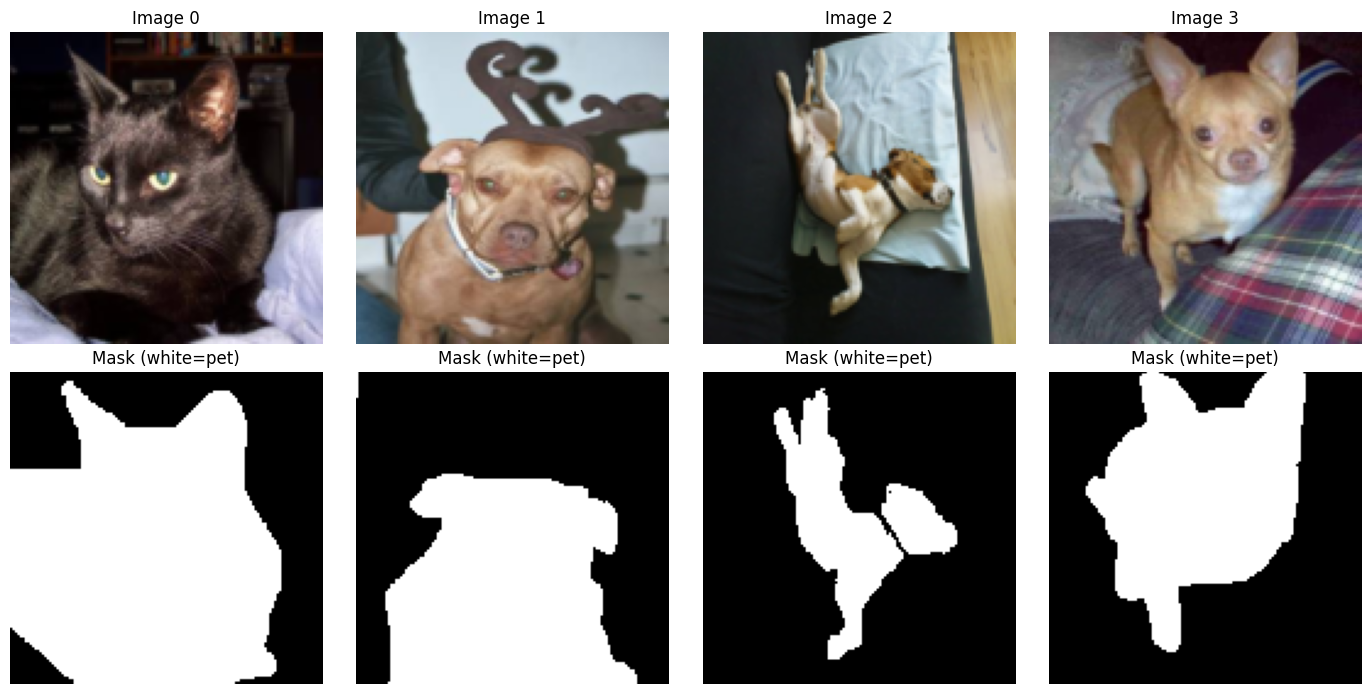

In [5]:
# Inspect one batch — shapes and value ranges
dm = PetSegDataModule()
dm.setup()

images, masks = next(iter(dm.train_dataloader()))
print(f"images: {tuple(images.shape)}  dtype={images.dtype}  "
      f"range=[{images.min():.2f}, {images.max():.2f}]")
print(f"masks:  {tuple(masks.shape)}   dtype={masks.dtype}   "
      f"unique values={masks.unique().tolist()}")

# Visual check — show 4 samples
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(denormalize(images[i]).permute(1, 2, 0))
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")
    axes[1, i].imshow(masks[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("Mask (white=pet)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

---
## 2 — U-Net Building Blocks

We build U-Net from four small modules and verify the tensor shapes as we go.

In [6]:
class DoubleConv(nn.Module):
    """Two Conv-BN-ReLU layers. padding=1 keeps the spatial size unchanged."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# Shape trace
x = torch.randn(2, 3, 128, 128)
dc = DoubleConv(3, 32)
y = dc(x)
print(f"DoubleConv(3 → 32):  {tuple(x.shape)}  →  {tuple(y.shape)}")
print(f"Spatial size unchanged:  {x.shape[2:]} == {y.shape[2:]}")
print(f"Parameters: {sum(p.numel() for p in dc.parameters()):,}")

DoubleConv(3 → 32):  (2, 3, 128, 128)  →  (2, 32, 128, 128)
Spatial size unchanged:  torch.Size([128, 128]) == torch.Size([128, 128])
Parameters: 10,208


In [13]:
class Down(nn.Module):
    """Encoder step: halve H,W with max-pool, then refine with DoubleConv."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.pool_conv(x)


# Shape trace — four consecutive Down steps
x = torch.randn(2, 3, 128, 128)
print(f"Input:                        {tuple(x.shape)}")
configs = [(3, 32), (32, 64), (64, 128), (128, 256), (256, 512)]
names   = ["stem (DoubleConv)", "down1", "down2", "down3", "down4 (bottleneck)"]
blocks  = [DoubleConv(3, 32)] + [Down(i, o) for i, o in configs[1:]]
for name, block in zip(names, blocks):
    x = block(x)
    print(f"{name:<25}  →  {tuple(x.shape)}")

Input:                        (2, 3, 128, 128)
stem (DoubleConv)          →  (2, 32, 128, 128)
down1                      →  (2, 64, 64, 64)
down2                      →  (2, 128, 32, 32)
down3                      →  (2, 256, 16, 16)
down4 (bottleneck)         →  (2, 512, 8, 8)


In [15]:
class Up(nn.Module):
    """Decoder step: upsample, concatenate the skip tensor, then refine."""

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # ConvTranspose2d doubles H,W and reduces the channel count by 2.
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        # After concatenation we mix decoder features with encoder detail.
        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)     # U-Net uses concatenation, not residual addition.
        return self.conv(x)


# Shape trace — one decoder step
x_bottleneck = torch.randn(2, 512, 8, 8)    # output of down4
x_skip = torch.randn(2, 256, 16, 16)  # skip from down3
up1 = Up(512, 256, 256)
y = up1(x_bottleneck, x_skip)
print(f"Up(512, skip=256 → 256):")
print(f"  bottleneck: {tuple(x_bottleneck.shape)}")
print(f"  skip:       {tuple(x_skip.shape)}")
print(f"  output:     {tuple(y.shape)}")

Up(512, skip=256 → 256):
  bottleneck: (2, 512, 8, 8)
  skip:       (2, 256, 16, 16)
  output:     (2, 256, 16, 16)


In [16]:
class OutConv(nn.Module):
    """
    1×1 convolution: maps C feature channels → num_classes logits per pixel.
    No activation here — the loss function handles that (sigmoid for binary,
    softmax inside CrossEntropyLoss for K > 2 classes).
    """

    def __init__(self, in_channels, num_classes=1):
        super().__init__()
        # 1×1 conv is equivalent to an independent linear projection at every pixel.
        self.conv = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# Shape trace — binary case (num_classes=1)
x = torch.randn(2, 32, 128, 128)
out = OutConv(32, num_classes=1)
y = out(x)
print(f"Binary OutConv(32, 1):  {tuple(x.shape)}  →  {tuple(y.shape)}")

# Shape trace — 3-class case
out3 = OutConv(32, num_classes=3)
y3  = out3(x)
print(f"3-class OutConv(32, 3):  {tuple(x.shape)}  →  {tuple(y3.shape)}")
print(f"Parameters (binary): {sum(p.numel() for p in out.parameters()):,}")

Binary OutConv(32, 1):  (2, 32, 128, 128)  →  (2, 1, 128, 128)
3-class OutConv(32, 3):  (2, 32, 128, 128)  →  (2, 3, 128, 128)
Parameters (binary): 33


---
## 3 — Full U-Net

The full model is a symmetric encoder-decoder with one skip connection per scale.

In [17]:
class UNet(nn.Module):
    """Binary U-Net: encoder down, decoder up, skip tensors across matching scales."""

    def __init__(self, base_channels=BASE_CHANNELS, num_classes=1):
        super().__init__()
        C = base_channels

        # Encoder
        self.stem  = DoubleConv(3, C)      
        
        self.down1 = Down(C, 2*C)           
        self.down2 = Down(2*C, 4*C)           
        self.down3 = Down(4*C, 8*C)           
        self.down4 = Down(8*C, 16*C)           

        # Decoder
        self.up1 = Up(16*C, 8*C, 8*C)      
        self.up2 = Up(8*C, 4*C, 4*C)      
        self.up3 = Up(4*C, 2*C, 2*C)      
        self.up4 = Up(2*C, C, C)         

        # Output: one logit per class per pixel. num_classes=1 for binary segmentation.
        self.out = OutConv(C, num_classes)    # 128×128,  C → num_classes

    def forward(self, x):
        # Save the activations we want to reuse in the decoder.
        s1 = self.stem(x)     # [B,  C, 128, 128]
        s2 = self.down1(s1)   # [B, 2C,  64,  64]
        s3 = self.down2(s2)   # [B, 4C,  32,  32]
        s4 = self.down3(s3)   # [B, 8C,  16,  16]
        x  = self.down4(s4)   # [B,16C,   8,   8]  bottleneck

        # Mirror the encoder: upsample, concatenate the matching skip, refine.
        x = self.up1(x, s4)  # [B, 8C,  16,  16]
        x = self.up2(x, s3)  # [B, 4C,  32,  32]
        x = self.up3(x, s2)  # [B, 2C,  64,  64]
        x = self.up4(x, s1)  # [B,  C, 128, 128]
        return self.out(x)    # [B, num_classes, 128, 128]

In [18]:
model  = UNet(base_channels=BASE_CHANNELS)
x      = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
y      = model(x)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Input:      {tuple(x.shape)}")
print(f"Output:     {tuple(y.shape)}")
print(f"Parameters: {n_params:,}")

assert y.shape == (2, 1, IMAGE_SIZE, IMAGE_SIZE), "Shape mismatch!"
print()
print("Shape check passed.")

Input:      (2, 3, 128, 128)
Output:     (2, 1, 128, 128)
Parameters: 7,763,041

Shape check passed.


---
## 4 — Loss and Metrics

We use BCE for per-pixel supervision and Dice for overlap. At evaluation time we threshold the sigmoid output and report hard Dice and IoU.

### Loss function: BCE + Soft Dice

Training minimises a **combined loss** that mixes two complementary signals:

$$\mathcal{L} = \mathcal{L}_{\text{BCE}} + \mathcal{L}_{\text{Dice}}$$

**Binary Cross-Entropy (BCE)** treats every pixel independently. For a predicted logit $\hat{y}$ and binary label $y \in \{0,1\}$ it penalises each pixel as:

$$\mathcal{L}_{\text{BCE}} = -\,y\log\sigma(\hat{y})\;-\;(1-y)\log(1-\sigma(\hat{y}))$$

where $\sigma$ is the sigmoid. BCE gives a dense, pixel-level gradient signal but is blind to the global shape of the mask.

**Soft Dice Loss** measures overlap between the predicted probability map and the target mask across the whole image:

$$\mathcal{L}_{\text{Dice}} = 1 - \frac{2\sum p_i\,y_i + \varepsilon}{\sum p_i + \sum y_i + \varepsilon}$$

Because it divides by the total predicted and true area, Dice is naturally robust to class imbalance — a common issue in segmentation where background pixels often vastly outnumber foreground pixels.

Using both losses together lets BCE provide sharp pixel-wise feedback while Dice pushes the model to produce spatially coherent, well-calibrated masks.

In [27]:
def dice_loss(logits, targets, eps=1e-6):
    """
    Soft Dice loss — operates on sigmoid probabilities, not binarized predictions.
    Fully differentiable; encourages the model to maximise mask overlap.
    """
    # Soft Dice uses probabilities, not thresholded predictions, so it stays differentiable.
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()


def segmentation_loss(logits, targets):
    """BCE (pixel-wise) + Dice (region-wise), equal weight."""
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss(logits, targets)
    return bce + dice


@torch.no_grad()
def batch_metrics(logits, targets, threshold=0.5):
    """
    Hard Dice and IoU for evaluation.
    Predictions are binarized at `threshold` before computing metrics.
    Returns (dice, iou) as Python floats.
    """
    # Metrics use hard masks because we want an interpretable overlap score.
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))
    dice = (2 * tp / (2 * tp + fp + fn + 1e-6)).mean()
    iou = (tp / (tp + fp + fn + 1e-6)).mean()
    return dice.item(), iou.item()


# Quick sanity check with random tensors
logits = torch.randn(4, 1, 128, 128)
targets = torch.randint(0, 2, (4, 1, 128, 128)).float()
loss = segmentation_loss(logits, targets)
dice, iou = batch_metrics(logits, targets)
print(f"Random baseline — loss: {loss:.3f}  dice: {dice:.3f}  iou: {iou:.3f}")
print("(Random predictions on balanced masks should give Dice ≈ 0.5, IoU ≈ 0.33)")

Random baseline — loss: 1.303  dice: 0.503  iou: 0.336
(Random predictions on balanced masks should give Dice ≈ 0.5, IoU ≈ 0.33)


---
## 5 — Lightning Module

Same training wrapper pattern as Lesson 2, with segmentation loss and Dice/IoU logging.

In [28]:
class LitUNet(pl.LightningModule):
    """Lightning wrapper."""

    def __init__(self, base_channels=BASE_CHANNELS, lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=MAX_EPOCHS):
        super().__init__()
        self.save_hyperparameters()
        self.model = UNet(base_channels=base_channels)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, stage):
        images, masks = batch
        logits = self(images)
        loss = segmentation_loss(logits, masks)
        # We log hard Dice/IoU for readability, while training uses soft Dice inside the loss.
        dice, iou = batch_metrics(logits, masks)

        self.log(f"{stage}/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(f"{stage}/dice", dice, on_step=False, on_epoch=True, prog_bar=(stage == "val"))
        self.log(f"{stage}/iou",  iou,  on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs,
        )
        return {
            "optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

    def on_train_start(self):
        n_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        self.logger.experiment.add_text(
            "model_info",
            f"**{self.__class__.__name__}** — {n_params:,} trainable parameters",
        )

---
## 6 — Training


In [29]:
def train_model(lit_model, experiment_name, max_epochs=MAX_EPOCHS, log_dir="tb_logs", model_dir="saved_models"):
    """Train one experiment and save the final checkpoint only if fit() completes."""
    
    os.makedirs(model_dir, exist_ok=True)
    ckpt_path = os.path.join(model_dir, f"{experiment_name}.ckpt")

    if os.path.exists(ckpt_path):
        print(f"\nSkipping '{experiment_name}' — completed checkpoint found.")
        print(f"  Load with: LitUNet.load_from_checkpoint('{ckpt_path}')\n")
        return None

    datamodule = PetSegDataModule()

    logger = TensorBoardLogger(save_dir=log_dir, name=experiment_name)

    callbacks = [
        LearningRateMonitor(logging_interval="epoch"),
        ModelCheckpoint(
            monitor="val/dice",
            mode="max",
            filename="best-{epoch:02d}-{val/dice:.3f}",
            save_top_k=1,
        ),
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",   
        devices=1,
        logger=logger,
        callbacks=callbacks,
        enable_progress_bar=True,
        deterministic=False,
    )

    trainer.fit(lit_model, datamodule=datamodule)

    trainer.save_checkpoint(ckpt_path)

    return trainer

In [30]:
#%load_ext tensorboard
#%tensorboard --logdir tb_logs

In [31]:
trainer = train_model(
    LitUNet(base_channels=BASE_CHANNELS),
    experiment_name="unet_pet_binary",
)


Skipping 'unet_pet_binary' — completed checkpoint found.
  Load with: LitUNet.load_from_checkpoint('saved_models/unet_pet_binary.ckpt')



---
## 7 — Results


Loaded tags: ['epoch', 'hp_metric', 'lr-Adam', 'train/dice', 'train/iou', 'train/loss', 'val/dice', 'val/iou', 'val/loss']


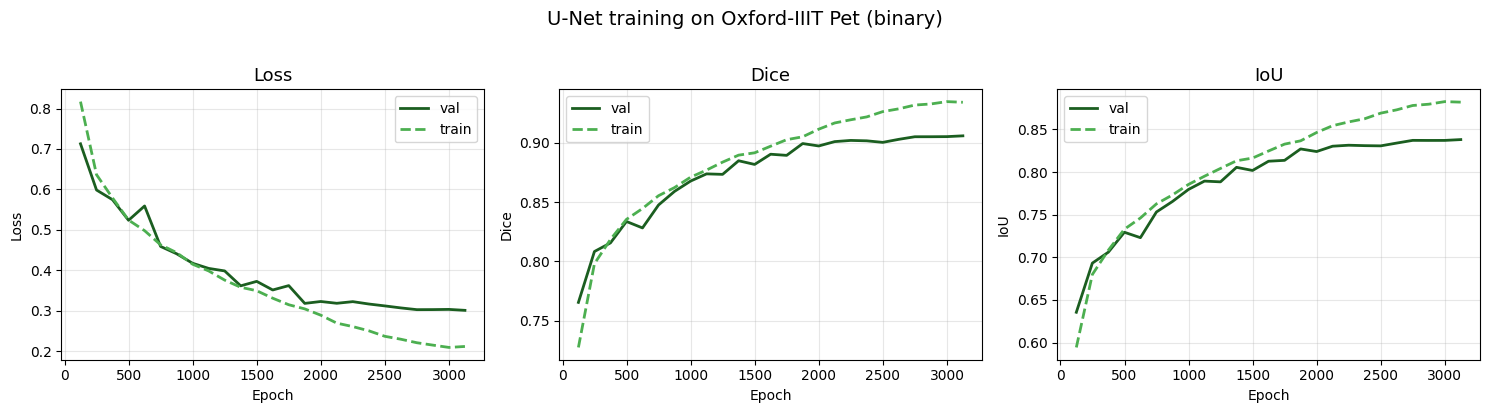

In [32]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def load_tb_scalars(log_dir="tb_logs", experiment="unet_pet_binary"):
    """Read TensorBoard scalars back into Python for plotting."""
    results = {}
    for version_dir in sorted(glob.glob(os.path.join(log_dir, experiment, "version_*"))):
        ea = EventAccumulator(version_dir)
        ea.Reload()
        for tag in ea.Tags().get("scalars", []):
            results[tag] = [(e.step, e.value) for e in ea.Scalars(tag)]
    return results


results = load_tb_scalars()
print(f"Loaded tags: {sorted(results.keys())}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

TRAIN_COLOR = "#4CAF50"
VAL_COLOR   = "#1B5E20"

for ax, val_tag, ylabel in zip(
    axes,
    ["val/loss", "val/dice", "val/iou"],
    ["Loss",     "Dice",     "IoU"],
):
    train_tag = val_tag.replace("val", "train")
    if val_tag in results:
        steps, values = zip(*results[val_tag])
        ax.plot(steps, values, color=VAL_COLOR,   linewidth=2, label="val")
    if train_tag in results:
        steps, values = zip(*results[train_tag])
        ax.plot(steps, values, color=TRAIN_COLOR, linewidth=2,
                linestyle="--", label="train")
    ax.set_title(ylabel, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("U-Net training on Oxford-IIIT Pet (binary)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
print(f"{'Metric':<20} {'Best value':>12}")
print("-" * 35)
for tag in ["val/dice", "val/iou", "val/loss"]:
    if tag in results:
        data = results[tag]
        best_fn = max if "loss" not in tag else min
        best    = best_fn(v for _, v in data)
        print(f"{tag:<20} {best:>12.4f}")

Metric                 Best value
-----------------------------------
val/dice                   0.9060
val/iou                    0.8381
val/loss                   0.3011


---
## 8 — Visualize Predictions

Look for coarse shape, edge quality, and typical failure cases.

Batch metrics — Dice: 0.896  IoU: 0.818


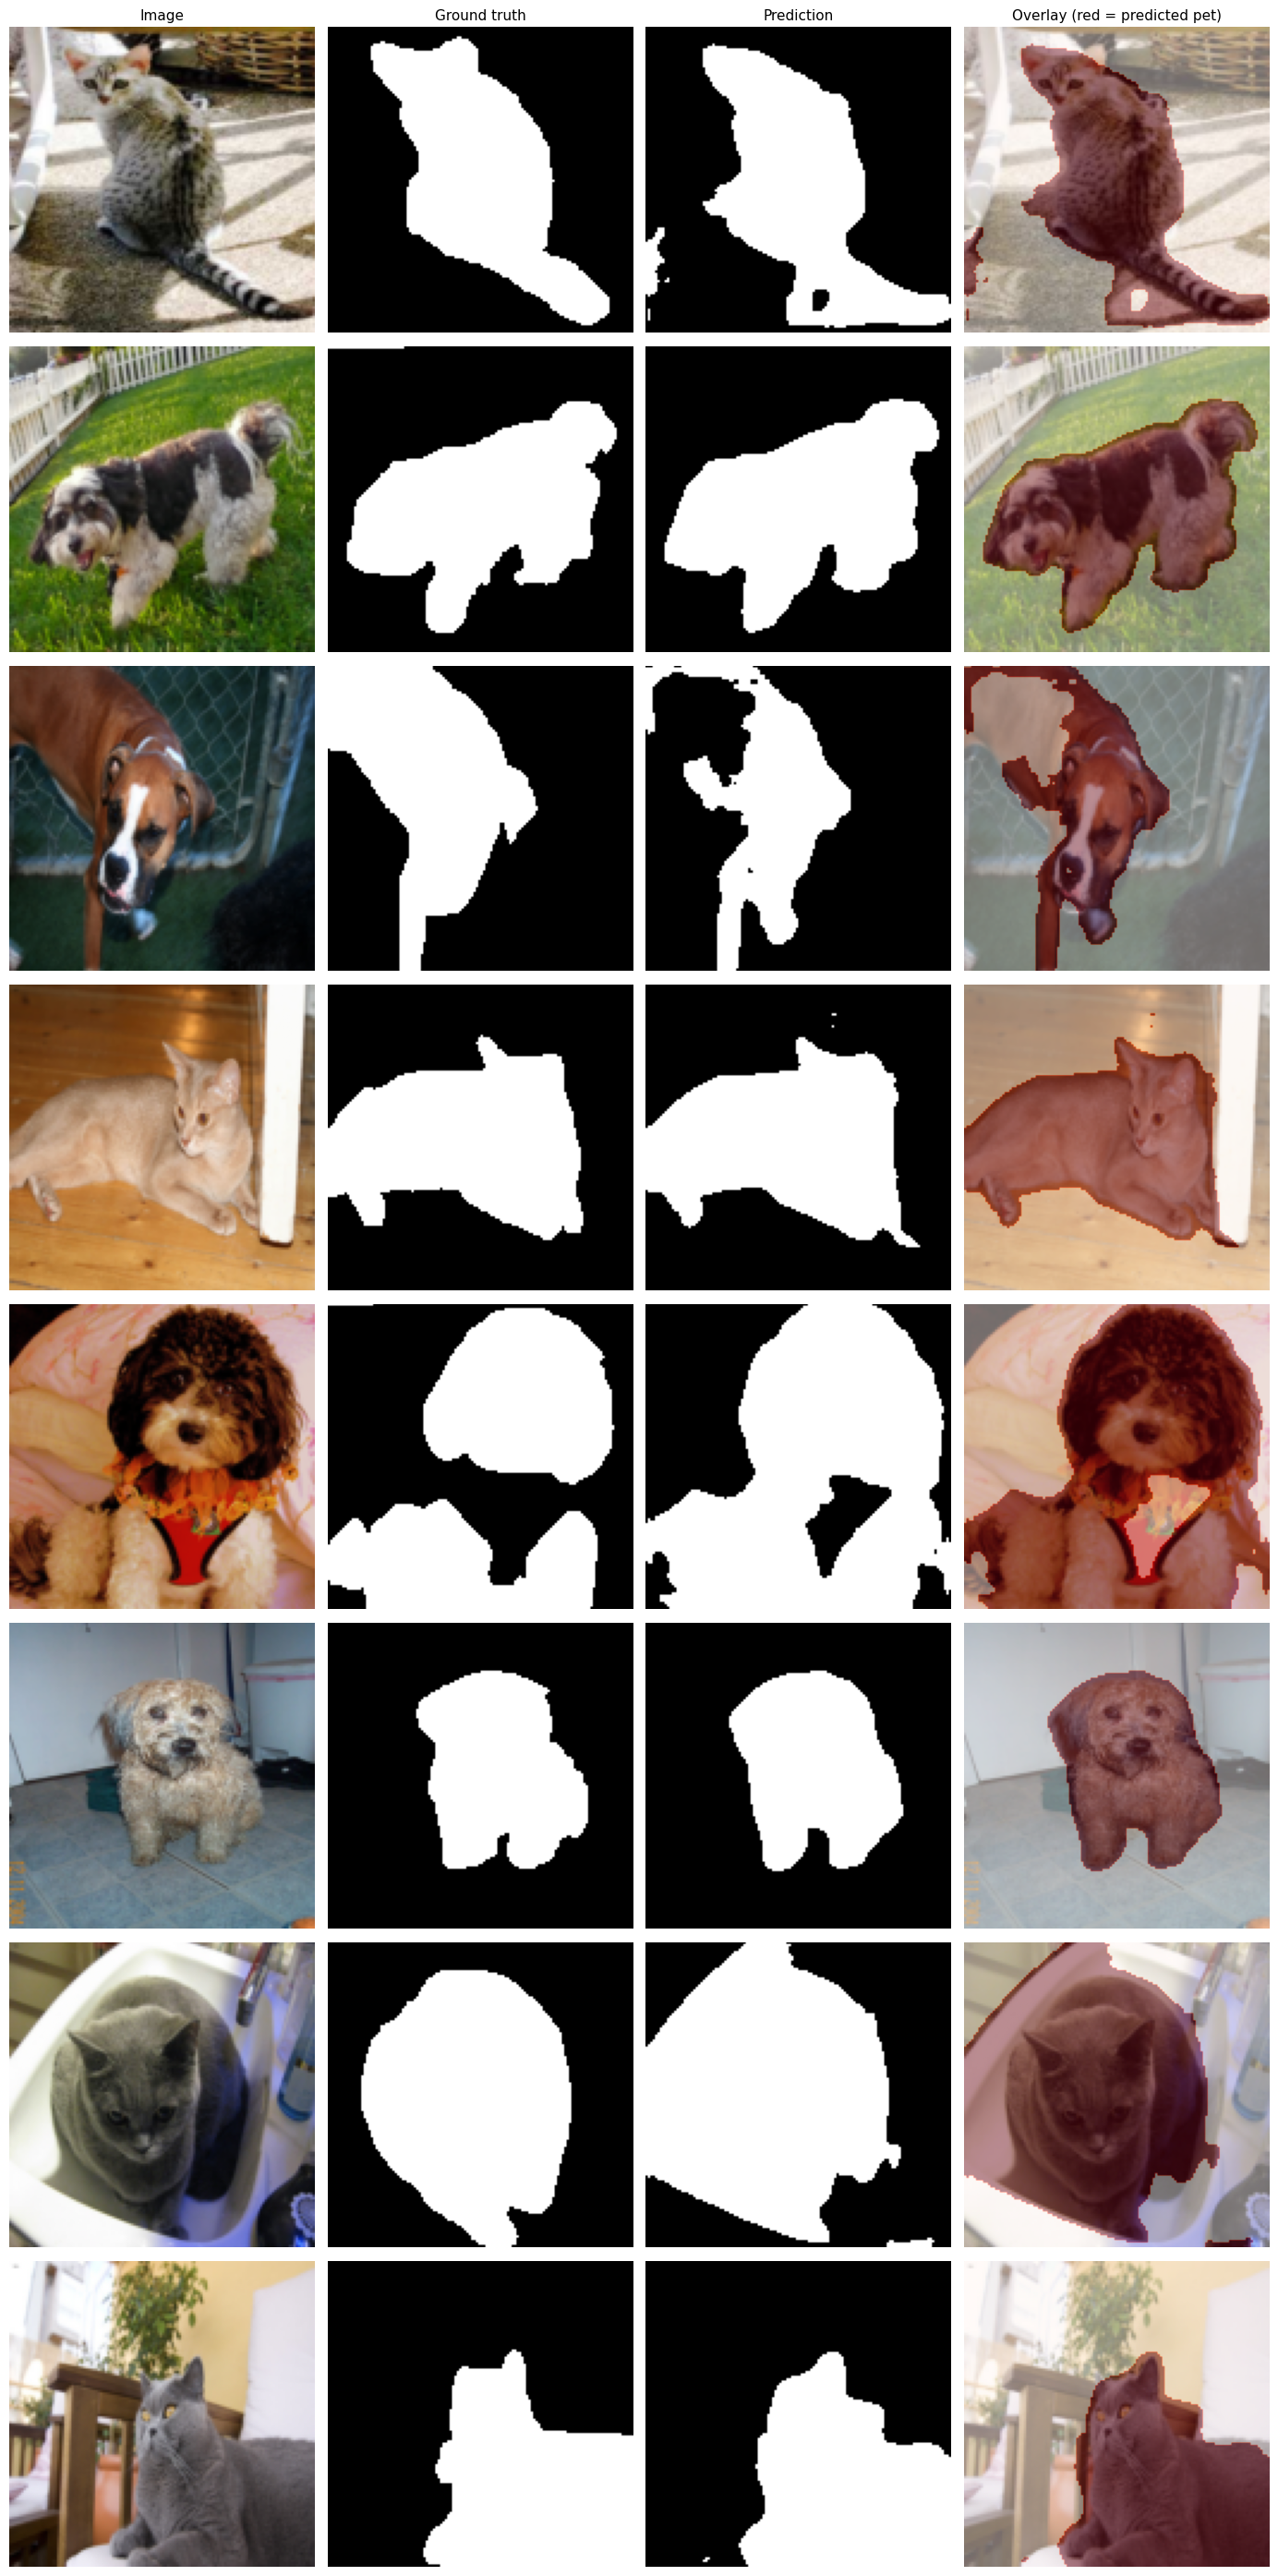

In [34]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

def visualize_predictions(lit_model, datamodule, n=4, split="val"):
    datamodule.setup()
    loader = datamodule.val_dataloader() if split == "val" else datamodule.test_dataloader()
    images, masks = next(iter(loader))
    images, masks = images[:n], masks[:n]

    lit_model.eval()
    with torch.no_grad():
        logits = lit_model(images)
    preds = (torch.sigmoid(logits) > 0.5).float()

    dice, iou = batch_metrics(logits, masks)
    print(f"Batch metrics — Dice: {dice:.3f}  IoU: {iou:.3f}")

    fig, axes = plt.subplots(n, 4, figsize=(14, n * 3.5))
    col_titles = ["Image", "Ground truth", "Prediction", "Overlay (red = predicted pet)"]

    for i in range(n):
        img_np = denormalize(images[i]).permute(1, 2, 0).numpy()
        mask_np = masks[i, 0].numpy()
        pred_np = preds[i, 0].numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        axes[i, 2].imshow(pred_np, cmap="gray", vmin=0, vmax=1)
        axes[i, 3].imshow(img_np)
        axes[i, 3].imshow(pred_np, cmap="Reds", alpha=0.45, vmin=0, vmax=1)

        for j in range(4):
            if i == 0:
                axes[i, j].set_title(col_titles[j], fontsize=11)
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


lit_model = LitUNet.load_from_checkpoint("saved_models/unet_pet_binary.ckpt")
dm = PetSegDataModule()
visualize_predictions(lit_model, dm, n=8)

---
## 9 — Exercises
1. Remove BatchNorm from `DoubleConv` and compare convergence..
2. Keep the full 3-class trimap and switch to `CrossEntropyLoss`.
3. Scale up to `BASE_CHANNELS = 64` and `IMAGE_SIZE = 256`.
4. Remove the skip connections (concatenation) and compare performance.